In [3]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.stats as spicy

In [4]:
rng = np.random.default_rng()
N = 1001
R = 1

In [5]:
x = rng.exponential(5.3, size = (R, N))
ndx = np.arange(1, N + 1)
cm = np.cumsum(x, axis = 1) / ndx

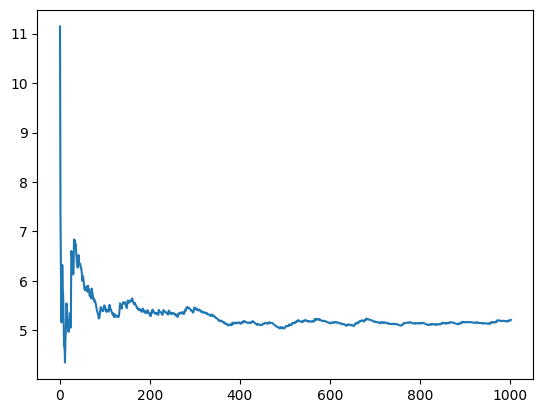

In [6]:
plt.plot(ndx, cm.T);

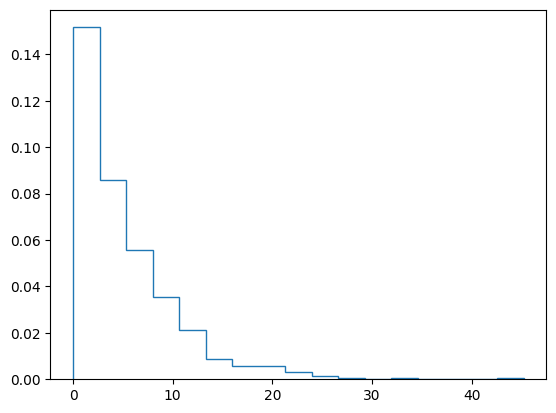

In [7]:
plt.hist(x[0], histtype = "step", density = True, bins = 17);

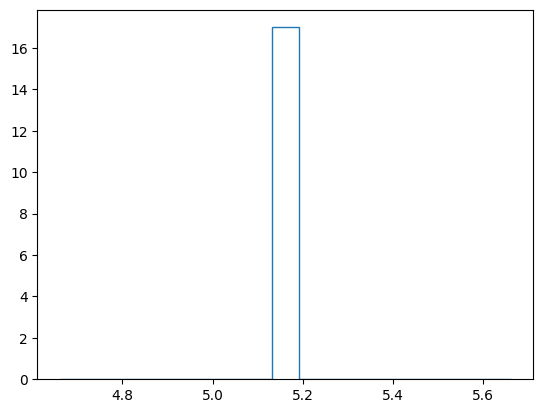

In [8]:
plt.hist(cm[:, 900], histtype = "step", density = True, bins = 17);

In [9]:
xbar = np.mean(x[0])
z = spicy.norm().ppf(0.975) # 95%
xbar - z * 5.3 / np.sqrt(np.size(x[0])), xbar + z * 5.3 / np.sqrt(np.size(x[0]))


(4.883685307715739, 5.54033979675485)

# Central Limit Theorem

Assume the random variables $X_1, \ldots, X_N$ are independent and all come from the same distribution, let's call this distribution $F$.  So long as $\mathbb{V}[X] = \sigma^2 < \infty$, then

$$\frac{\bar{X} - \mu}{\sigma / \sqrt{N}} \quad \dot{\sim} \quad \text{Normal}(0, 1)$$

where $\mathbb{E}[X] = \mu$.

Note that we don't care what $F$ looks like, symmetric, skewed, multi-modal.  So long as $F$ has finite variance, then the mean of random variables from $F$ is itself a random variable.  The Central Limit Theorem says that the approximate shape of $\bar{X}$, after centering and scaling it appropriately, is a standard Normal distribution (located/centered at $0$ and scaled to a variance of $1$). 

Because of the Central Limit Theorem, we can theoretically calculate probabilities that the random variable $\frac{\bar{X} - \mu}{\sigma/\sqrt{N}}$ is between two numbers $-z, z$.  In fact, we can find a number $z$ such that the probability is equal to say 0.95,

$$\mathbb{P}\left[-z \leq \frac{\bar{X} - \mu}{\sigma/\sqrt{N}} \leq z\right] = 0.95$$

In [10]:
spicy.norm().ppf(0.975) # for 95%, z = 

1.959963984540054

Re-working the inequality inside the probability statement gives us a way to bound with a specified probability the expectation, $\mu = \mathbb{E}[X]$.

$$\mathbb{P}\left[\bar{X} - z \sigma / \sqrt{N} \leq \mu \leq \bar{X} + z \sigma / \sqrt{N} \right]$$

Hence, a reasonable starting point to bound with high probability the expectation $\mu = \mathbb{E}[X]$ is

$$\bar{X} \pm z \sigma / \sqrt{N}$$

The problem is that this formula requires knowledge of the standard deviation $\sigma = \sqrt{\mathbb{V}[X]}$.  Since it is extremely unlikely that we have this, we'll have to estimate it, too. We'll have to estimate both the expectation with $\bar{X}$ and the standard deviation.  We next to turn confidence intervals under the t-distribution.